In [1]:
# Tratamiento de datos
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd

# Gráficos
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Preprocesado y modelado
# ------------------------------------------------------------------------------
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

# Configuración warnings
# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('once')

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('encoded.csv')
datos = df
datos.head()

,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_11,p_12,...,p_21,p_22,p_23,p_24,p_25,p_26,p_27,p_28,p_29,p_30
0,0,0,3,0,1,0,0,89,0,0,...,41,1,33,5,0,0,1,12,15,246
1,1,0,3,0,2,0,1,133,0,0,...,40,1,29,5,0,0,2,29,16,136
2,1,0,6,1,1,2,0,0,0,0,...,40,1,6,5,0,0,0,28,8,136
3,0,0,6,0,2,0,1,134,0,0,...,40,1,37,1,0,0,0,6,4,159
4,1,0,6,0,1,0,0,133,0,0,...,40,1,58,5,0,0,0,12,24,144


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   p_1     2535 non-null   int64
 1   p_2     2535 non-null   int64
 2   p_3     2535 non-null   int64
 3   p_4     2535 non-null   int64
 4   p_5     2535 non-null   int64
 5   p_6     2535 non-null   int64
 6   p_7     2535 non-null   int64
 7   p_8     2535 non-null   int64
 8   p_11    2535 non-null   int64
 9   p_12    2535 non-null   int64
 10  p_13    2535 non-null   int64
 11  p_14    2535 non-null   int64
 12  p_15    2535 non-null   int64
 13  p_16    2535 non-null   int64
 14  p_17    2535 non-null   int64
 15  p_18    2535 non-null   int64
 16  p_19    2535 non-null   int64
 17  p_20    2535 non-null   int64
 18  p_21    2535 non-null   int64
 19  p_22    2535 non-null   int64
 20  p_23    2535 non-null   int64
 21  p_24    2535 non-null   int64
 22  p_25    2535 non-null   int64
 23  p_26    2535 

In [4]:
# División de los datos en train y test
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
                                        datos.drop(columns = "p_7"),
                                        datos['p_7'],
                                        random_state = 123
                                    )
# Creación del modelo
# ------------------------------------------------------------------------------
modelo = DecisionTreeRegressor(
            max_depth         = 3,
            random_state      = 123
          )

# Entrenamiento del modelo
# ------------------------------------------------------------------------------
modelo.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=123)

Profundidad del árbol: 3
Número de nodos terminales: 8


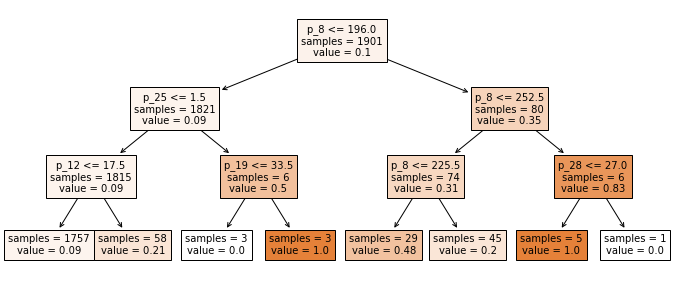

In [5]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5))

print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de nodos terminales: {modelo.get_n_leaves()}")

plot = plot_tree(
            decision_tree = modelo,
            feature_names = datos.drop(columns = "p_7").columns,
            class_names   = 'p_7',
            filled        = True,
            impurity      = False,
            fontsize      = 10,
            precision     = 2,
            ax            = ax
       )


In [6]:
texto_modelo = export_text(
                    decision_tree = modelo,
                    feature_names = list(datos.drop(columns = "p_7").columns)
               )
print(texto_modelo)

|--- p_8 <= 196.00
|   |--- p_25 <= 1.50
|   |   |--- p_12 <= 17.50
|   |   |   |--- value: [0.09]
|   |   |--- p_12 >  17.50
|   |   |   |--- value: [0.21]
|   |--- p_25 >  1.50
|   |   |--- p_19 <= 33.50
|   |   |   |--- value: [0.00]
|   |   |--- p_19 >  33.50
|   |   |   |--- value: [1.00]
|--- p_8 >  196.00
|   |--- p_8 <= 252.50
|   |   |--- p_8 <= 225.50
|   |   |   |--- value: [0.48]
|   |   |--- p_8 >  225.50
|   |   |   |--- value: [0.20]
|   |--- p_8 >  252.50
|   |   |--- p_28 <= 27.00
|   |   |   |--- value: [1.00]
|   |   |--- p_28 >  27.00
|   |   |   |--- value: [0.00]



In [7]:
importancia_predictores = pd.DataFrame(
                            {'predictor': datos.drop(columns = "p_7").columns,
                             'importancia': modelo.feature_importances_}
                            )
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
6,p_8,0.659511
15,p_19,0.122743
21,p_25,0.082338
24,p_28,0.068191
8,p_12,0.067216
0,p_1,0.000000
25,p_29,0.000000
23,p_27,0.000000
22,p_26,0.000000
20,p_24,0.000000


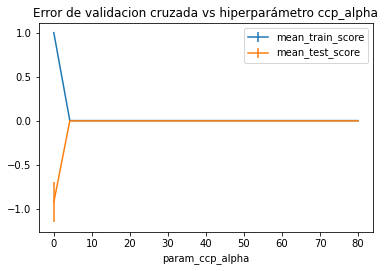

In [8]:
# Pruning (const complexity pruning) por validación cruzada
# ------------------------------------------------------------------------------
# Valores de ccp_alpha evaluados
param_grid = {'ccp_alpha':np.linspace(0, 80, 20)}

# Búsqueda por validación cruzada
grid = GridSearchCV(
        # El árbol se crece al máximo posible para luego aplicar el pruning
        estimator = DecisionTreeRegressor(
                            max_depth         = None,
                            min_samples_split = 2,
                            min_samples_leaf  = 1,
                            random_state      = 123
                       ),
        param_grid = param_grid,
        cv         = 10,
        refit      = True,
        return_train_score = True
      )

grid.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");

In [9]:
# Mejor valor ccp_alpha encontrado
# ------------------------------------------------------------------------------
grid.best_params_

{'ccp_alpha': 4.2105263157894735}

Profundidad del árbol: 0
Número de nodos terminales: 1


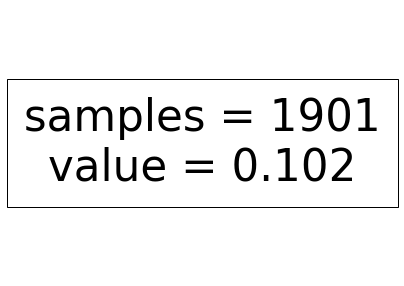

In [10]:
# Estructura del árbol final
# ------------------------------------------------------------------------------
modelo_final = grid.best_estimator_
print(f"Profundidad del árbol: {modelo_final.get_depth()}")
print(f"Número de nodos terminales: {modelo_final.get_n_leaves()}")

fig, ax = plt.subplots(figsize=(7, 5))
plot = plot_tree(
            decision_tree = modelo_final,
            feature_names = datos.drop(columns = "p_7").columns,
            class_names   = 'p_7',
            filled        = True,
            impurity      = False,
            ax            = ax
       )



In [11]:
# Error de test del modelo inicial
#-------------------------------------------------------------------------------
predicciones = modelo.predict(X = X_test)

rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = predicciones,
        squared = False
       )
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 0.25643104789260246


In [12]:
# Error de test del modelo final (tras aplicar pruning)
#-------------------------------------------------------------------------------
predicciones = modelo_final.predict(X = X_test)

rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = predicciones,
        squared = False
       )
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 0.26346980779816115
